# <font color="steelblue">Módulo Numpy</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 10/05/2025

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

## <font color='steelblue'>Introducción</font>

**Descripción:** NumPy es una librería de Python muy popular que proporciona una forma eficiente de trabajar con matrices y arrays multidimensionales. En este cuaderno introducimos las matrices bidimensionales identificándolas como imágenes en escala de gris. Operar una matriz equivale pues, a modificar la imagen que la representa. Aprendemos a crear y manipular matrices, y en consecuencia imágenes 2D en escala de gris. Además introducimos las matrices o arrays tridimensionales, identificando su utilidad para representar secuencias de imágenes como las que genera la tomografía axial computerizada (TAC), imágenes en color, o incluso imágenes satelitales. Se trabaja el procesado básico de estas imágenes con filtros, selecciones y recortes.



## <font color='steelblue'> Objetivos de aprendizaje

* Descubrir el módulo *NumPy* y sus objetos base llamados *arrays*.

* Identificar las matrices con la representación de imágenes en 2D.

* Identificar los conceptos de celda/cuadrícula en matrices y píxeles en imágenes.

* Aprender a crear matrices y representarlas como imágenes 2D en escala de grises.

* Entender que el procesado de imágenes consiste en la manipulación (operaciones y transformaciones) de las matrices que las representan.

* Aprender a procesar imágenes de modo básico a través de la manipulación de las matrices que las representan.

* Conocer la estructura de las matrices tridimensionales en NumPy y su uso para la representación de imágenes en tres dimensiones.

* Aprender a leer y manipular secuencias de imágenes en blanco y negro de un TAC.

* Aprender a leer y manipular imágenes a color y con transparencia.



## <font color='steelblue'> Contenidos </font>

1. Introducción a NumPy
1. Creación de imágenes con matrices 2D
1. Manipulación de imágenes por píxeles
1. Manipulación de imágenes por secciones
1. Procesado básico de imágenes
1. Matrices tridimensionales
1. Imágenes 3D en blanco y negro
1. Imágenes a color y matrices 3D

## <font color='steelblue'> 1. Introducción a NumPy

### <font color='steelblue'> ¿Qué es NumPy?

​​*NumPy* (Numerical Python) es el paquete de código abierto fundamental para la computación científica en Python, utilizado en casi todos los campos de la ciencia y la ingeniería. Es el estándar universal para trabajar con datos numéricos en *Python* y es el núcleo de los ecosistemas científicos de *Python* y *PyData*. Entre sus usuarios se encuentran desde codificadores principiantes hasta investigadores experimentados que realizan investigación y desarrollo científico e industrial de vanguardia.

Esta librería de *Python* proporciona un tipo de objeto de matriz multidimensional, varios objetos derivados (como matrices y matrices enmascaradas) y una variedad de rutinas para operaciones rápidas con matrices, que incluyen manipulación matemática, lógica, de formas, clasificación, selección, transformadas discretas de Fourier, álgebra lineal básica, operaciones estadísticas básicas, simulación aleatoria y mucho más. También agrega poderosas estructuras de datos a *Python* que garantizan cálculos eficientes con arrays y matrices, y proporciona una enorme librería de funciones matemáticas de alto nivel que operan con ellos. Además de sus usos científicos obvios, *NumPy* también puede ser utilizado como un eficiente contenedor multidimensional de datos genéricos, lo que permite que pueda integrarse de forma transparente y rápida con una amplia variedad de bases de datos.

Para comenzar a utilizar Numpy debemos importar la librería con la instrucción `import`, siendo habitual utilizar el alias `np` para simplificar su uso:




In [69]:
import numpy as np

En la documentación oficial de la [libreria NumPy](https://numpy.org/), podemos encontrar una guía para principiantes en https://numpy.org/doc/stable/user/absolute_beginners.html

### <font color='steelblue'> Vectores y secuencias con Numpy


Podemos definir vectores de forma muy sencilla mediante listas o a través de la función `range()`

In [70]:
# Vectores
x = list(range(1,8,2))
x_vec = np.array(x)
print(x_vec)

[1 3 5 7]


In [71]:
# secuencias continuas
x = np.arange(15,20,0.3)
print(x)

[15.  15.3 15.6 15.9 16.2 16.5 16.8 17.1 17.4 17.7 18.  18.3 18.6 18.9
 19.2 19.5 19.8]


In [72]:
# secuencias enriquecidas
x = np.linspace(start = 5,stop = 50,num = 20,endpoint = True)
print(x)

[ 5.          7.36842105  9.73684211 12.10526316 14.47368421 16.84210526
 19.21052632 21.57894737 23.94736842 26.31578947 28.68421053 31.05263158
 33.42105263 35.78947368 38.15789474 40.52631579 42.89473684 45.26315789
 47.63157895 50.        ]


In [73]:
# Los ordenamos con sort
x = np.array([2,8,4,7,1,0])
print("Este es x ",x," y este x ordenado ",np.sort(x))

Este es x  [2 8 4 7 1 0]  y este x ordenado  [0 1 2 4 7 8]


In [74]:
# generamos números aleatorios enteros y float
from numpy import random
x=random.randint(10,size=4)
y=random.rand(4)*10   # se generan entre 0 y 1
print(x,y)

[5 1 7 1] [7.17052495 3.99786488 3.48764984 5.73191134]


### <font color='steelblue'> Matrices en Python y Numpy

Para empezar a describir el funcionamiento de *NumPy*, es fundamental entender las estructuras básicas de información que maneja este módulo, esto es, las matrices.

Matemáticamente, una matriz es un conjunto bidimensional de números que se organizan en filas y columnas. Una matriz con dos filas y dos columnas se representa según:

$$A = \begin{pmatrix}
a_{11} & a_{12} \\
a_{21} & a_{22}
\end{pmatrix}$$

En las matrices, el orden de lectura es: primero las filas y después las columnas. Es decir, el elemento $a_{12}$ nos indica que se encuentra en la fila número 1 y en la columna número 2.

*Python* sin embargo, no tiene un tipo de objeto específico para representar matrices, y se crean y operan a partir de listas anidadas. Así por ejemplo, si queremos escribir en Python la matriz  

$$A = \begin{pmatrix}
1 & 2 \\
3 & 4
\end{pmatrix}$$

escribiremos una lista que contiene dos listas, una para cada fila, y cada una de ellas con los elementos de la fila correspondiente:





In [75]:
# definición de matrices en Python
A = [[1,2],[3,4]]

Para seleccionar sus elementos utilizamos los corchetes de selección: el primer corchete para las filas y el segundo para las columnas, recordando que la indexación entera en Python se inicializa en cero:

In [76]:
print("A=",A)
# primera fila
print("A[1,]=",A[0])
# primera fila y primera columna
print("A[1,1]=",A[0][0])
# última fila y última columna
print("A[2,2]=",A[-1][-1])

A= [[1, 2], [3, 4]]
A[1,]= [1, 2]
A[1,1]= 1
A[2,2]= 4


Con *NumPy* se pueden generar matrices más fácilmente y también con más de dos dimensiones. De hecho, *NumPy* nos brinda una enorme variedad de formas rápidas y eficientes de crear matrices, o *arrays*, y manipular datos numéricos dentro de ellas.

Si bien una lista de *Python* puede contener diferentes tipos de datos dentro de una misma lista, todos los elementos de una matriz *NumPy* deben ser **homogéneos** para garantizar mayor eficiencia en los cálculos; así todos ellos son de un tipo denominado **matrix.dtype**

Una **matriz** o **array** en *NumPy* es la estructura base de datos en este módulo, organizados en una cuadrícula de valores, y donde cada cuadrícula da una información diferenciada. La cuadrícula se puede indexar de varias maneras (por una tupla de enteros no negativos, por valores booleanos, por otra matriz o por enteros).

Así, una forma de crear una matriz de Numpy es a partir de las listas anidadas con las que definimos matrices en Python, utilizando la **función `np.array()`**. Veremos más adelante otras formas de crear matrices con *NumPy*.


In [77]:
# matriz en Python
A = [[1,2],[3,4]]
print("Matriz en Python: \n",A)
# matriz en Numpy
A = np.array([[1,2],[3,4]])
print("Matriz en NumPy: \n ",A)

Matriz en Python: 
 [[1, 2], [3, 4]]
Matriz en NumPy: 
  [[1 2]
 [3 4]]


Cuando tenemos una matriz cualquiera definida como `array` de `NumPy`, podemos calcular su dimensión con la **función `shape`**, que nos da el número de filas y el de columnas.

In [78]:
A.shape

(2, 2)

Definimos matrices a través de listas concatenadas con comas.

In [79]:
# Matrices
x=np.array([1,3,5,7])
y=np.arange(2,10,2)
xy_mat=np.array([x,
                y])
print("x=",x,"y=",y,"\se unen para crear la matriz \n",xy_mat,
      "de dimensión", np.shape(xy_mat))

x= [1 3 5 7] y= [2 4 6 8] \se unen para crear la matriz 
 [[1 3 5 7]
 [2 4 6 8]] de dimensión (2, 4)


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3126900041.py:6: SyntaxWarning: invalid escape sequence '\s'
  print("x=",x,"y=",y,"\se unen para crear la matriz \n",xy_mat,


Para crear matrices a partir de vectores y dando el número de filas y columnas, usamos reshape.

In [80]:
a=np.arange(10,100,10)
print(len(a))
a_mat=np.reshape(a,[3,3])
print(a_mat)

9
[[10 20 30]
 [40 50 60]
 [70 80 90]]


In [81]:
# Podemos crear matrices pegando vectores por filas o columnas
arr1 = np.array([1,2,3])
arr2 = np.array([5,6,7])
arr_c = np.stack((arr1, arr2), axis=1)
arr_f = np.stack((arr1, arr2), axis=0)
print("Pegamos por filas \n",arr_f,"\n y por columnas \n",arr_c)

Pegamos por filas 
 [[1 2 3]
 [5 6 7]] 
 y por columnas 
 [[1 5]
 [2 6]
 [3 7]]


Para crear matrices que replican (por filas o columnas) un vector, tenemos dos opciones:

In [82]:
# opción1. Crear una matriz vacía y rellenarla con un bucle
v=[0,1,0]
# creamos una matriz vacía con la dimensión que queramos
v_mat=np.empty([3,3])
for i in range(3):
  v_mat[i,:]=v
print(v_mat)

[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [83]:
# opción2. Replicar el vector y apilarlo en filas
v_mat2=np.tile(v,(3,1)) # por columnas sólo queremos 1 réplica
print(v_mat2)

[[0 1 0]
 [0 1 0]
 [0 1 0]]


In [84]:
# Unimos arrays por columnas
arr1 = np.array([[1, 2], [3, 4]])
arr2 = np.array([[5, 6], [7, 8]])
arr = np.concatenate((arr1, arr2), axis=1)
print("Unimos matrices por columnas \n",arr)

Unimos matrices por columnas 
 [[1 2 5 6]
 [3 4 7 8]]


Y podemos definir matrices estándar, como matrices constantes (full), identidad (eye), de ceros (zeros), de unos (ones) e incluso aleatorias (random.randint)

In [85]:
# Matriz cero y matrices con todos los elementos iguales
a=np.zeros((2,2))
b=np.ones((2,2))
c=np.full((2,2),10,dtype=int)
print("Matriz cero \n",a,
      "\n  matriz de unos \n",b,
      "\n matriz con todos los elementos iguales \n",c)

Matriz cero 
 [[0. 0.]
 [0. 0.]] 
  matriz de unos 
 [[1. 1.]
 [1. 1.]] 
 matriz con todos los elementos iguales 
 [[10 10]
 [10 10]]


In [86]:
# Matriz identidad
a=np.eye(2); print(a)

[[1. 0.]
 [0. 1.]]


In [87]:
# Matriz generada con números aleatorios enteros
a=np.random.randint(20,size=(2,2)); print(a)

[[13 15]
 [ 3  9]]


Cuando queremos **iterar** sobre los elementos de un array, interesan los comandos row que identifican las filas, y element, que se moverán por las columnas:

In [88]:
c=np.array([[1,5,3],[2,7,1],[6,9,4]])
# Pintamos las columnas de la segunda fila
for element in c[1,:]:
  print(element)

2
7
1


In [89]:
# Pintamos las filas íntegras, y a continuación cada elemento de sus columnas
for row in c:
  for element in row:
    print("fila=",row,"columna=",element)

fila= [1 5 3] columna= 1
fila= [1 5 3] columna= 5
fila= [1 5 3] columna= 3
fila= [2 7 1] columna= 2
fila= [2 7 1] columna= 7
fila= [2 7 1] columna= 1
fila= [6 9 4] columna= 6
fila= [6 9 4] columna= 9
fila= [6 9 4] columna= 4


In [90]:
# enumerate nos facilita el movimiento por todos los elementos
for row_idx, row in enumerate(c):
    print("La fila ", row_idx, " es ", row)
    for col_idx, element in enumerate(row):
        print("la columna ", col_idx, " tiene el valor ", element)
        # y la actualización de sus valores, elevándolos al cuadrado
        c[row_idx, col_idx] = element ** 2
print(c)


La fila  0  es  [1 5 3]
la columna  0  tiene el valor  1
la columna  1  tiene el valor  5
la columna  2  tiene el valor  3
La fila  1  es  [2 7 1]
la columna  0  tiene el valor  2
la columna  1  tiene el valor  7
la columna  2  tiene el valor  1
La fila  2  es  [6 9 4]
la columna  0  tiene el valor  6
la columna  1  tiene el valor  9
la columna  2  tiene el valor  4
[[ 1 25  9]
 [ 4 49  1]
 [36 81 16]]


### <font color='steelblue'> Álgebra lineal

Veamos cómo se calculan fácilmente las operaciones habituales con vectores y matrices, disponibles íntegramente en numpy.org. Algunas de estas funciones las tenemos en el paquete linalg de Numpy. La documentación la podemos consultar con help(np.linalg).

Las operaciones básicas en Numpy son: len (longitud o nº filas), shape (dimensión), T (trasposición), sum(suma elementos de un array), add (adición), subtract (substracción), multiply (multiplicación elemento a elemento),divide (división elemento a elemento), sqrt (raíz cuadrada), dot(producto escalar de vectores y producto matricial, inversas, determinantes de matrices, valores y vectores propios, ...

Veamos algunos ejemplos.

In [91]:
# Producto escalar de dos vectores con dos funciones
v1=np.array([1,2,3])
v2=np.array([3,4,5])
print(np.dot(v1,v2),np.inner(v1,v2))

26 26


In [92]:
# Partimos de dos matrices y calculamos su dimensión
x=np.array([[1,2,3],[4,5,6]])
y=np.array([[4,5,6],[1,2,3]])
print("x es: \n", x, "\n y es: \n", y, "\n ambas de dimensión ",x.shape)

x es: 
 [[1 2 3]
 [4 5 6]] 
 y es: 
 [[4 5 6]
 [1 2 3]] 
 ambas de dimensión  (2, 3)


In [93]:
# Podemos sumar sus elementos, por filas o columnas (ojo: estaremos sumando vectores)
print("La suma de las filas de x es: ",np.sum(x,axis=1),
      "y de sus columnas: ",np.sum(x,axis=0))

La suma de las filas de x es:  [ 6 15] y de sus columnas:  [5 7 9]


In [94]:
# Suma y producto de matrices, elemento a elemento
print("Suma de x e y: \n",np.add(x,y),
      "\n Producto de elementos: \n",np.multiply(x,y))

Suma de x e y: 
 [[5 7 9]
 [5 7 9]] 
 Producto de elementos: 
 [[ 4 10 18]
 [ 4 10 18]]


In [95]:
# Producto matricial
print("Producto matricial x'y con dot: \n",np.dot(x.T,y),
      "\n y con @ \n",x.T @ y)

Producto matricial x'y con dot: 
 [[ 8 13 18]
 [13 20 27]
 [18 27 36]] 
 y con @ 
 [[ 8 13 18]
 [13 20 27]
 [18 27 36]]


In [96]:
# Calculamos el determinante
c=np.array([[1,5,3],[2,7,1],[6,9,4]])
print("Esta es c \n",c,"\n y este su determinante \n", np.linalg.det(c))

Esta es c 
 [[1 5 3]
 [2 7 1]
 [6 9 4]] 
 y este su determinante 
 -62.99999999999999


In [97]:
# Calculamos la inversa de la matriz
np.linalg.inv(c)

array([[-0.3015873 , -0.11111111,  0.25396825],
       [ 0.03174603,  0.22222222, -0.07936508],
       [ 0.38095238, -0.33333333,  0.04761905]])

In [98]:
# Calculamos los valores y vectores propios
np.linalg.eig(c)

EigResult(eigenvalues=array([11.33301218, -2.04772411,  2.71471192]), eigenvectors=array([[-0.42425328, -0.77903483,  0.38233338],
       [-0.38498361,  0.10386614, -0.3754637 ],
       [-0.8196321 ,  0.61831752,  0.84430338]]))

## <font color='steelblue'> 2. Creación de imágenes con matrices 2D

Puesto que vamos a trabajar con imágenes y su visualización, utilizaremos, además de **NumPy**, el módulo de visualización **matplotlib**, que importamos para hacerlo operativo:

In [99]:
# Inicialización de módulos
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### <font color='steelblue'>Una imagen como matriz

Las imágenes que vamos a trabajar en este cuaderno serán imágenes en escala de grises, donde los colores se definen con números que van desde el 0, que representa el negro, al 255, que representa el blanco. Un número próximo a 0 será un gris oscuro, y un número próximo a 255  un gris claro.

Pues bien, vamos a crear en primer lugar una matriz de 2 filas y 2 columnas, esto es, 4 cuadrados o celdas. Además, queremos rellenar de blanco los cuadrados de la diagonal principal (arriba izquierdo y abajo derecho) y en negro los restantes.
Así pues, creamos una lista cuyos elementos son dos listas, una por cada fila: `[255,0]` para la primera fila y `[0,255]` para la segunda, y le aplicamos la función `np.array()`.




In [100]:
matriz22 = np.array([[255, 0], [0, 255]])
print(matriz22)

[[255   0]
 [  0 255]]


Las matrices son pues, como ya dijimos, cuadrículas que contienen valores numéricos. Una matriz que representa una imagen contiene, en cada celda, un número que representa el nivel de gris con el que rellenamos esa parte de la imagen. Veamos a continuación las imágenes que vienen representadas por las matrices que hemos definido.

### <font color='steelblue'>Dibujar una imagen

Para pintar las matrices que hemos definido y mostrar cómo representan imágenes, vamos a construir una **función `dibujar()`** que reciba como argumento una matriz (de escala de grises) y que la pinte como imagen. Para ello utilizamos las funciones de  `matplotlib`:
- `figure`, para especificar el tamaño de la figura,
- `imshow`, específica para pintar una imagen, que recibe como argumento la matriz de color, y en la que hay que especificar que viene dada en escala de grises, `cmap='gray'`, en la que el rango de valores para los colores va de `vmin=0` hasta `vmax=255`.

In [101]:
def dibujar(matriz):
  # tamaño
  plt.figure(figsize=(6,6))
  # dibujo de la imagen en escala de grises
  plt.imshow(matriz, cmap="gray", vmin=0, vmax=255)

Procedemos pues a visualizar las matrices que hemos creado:

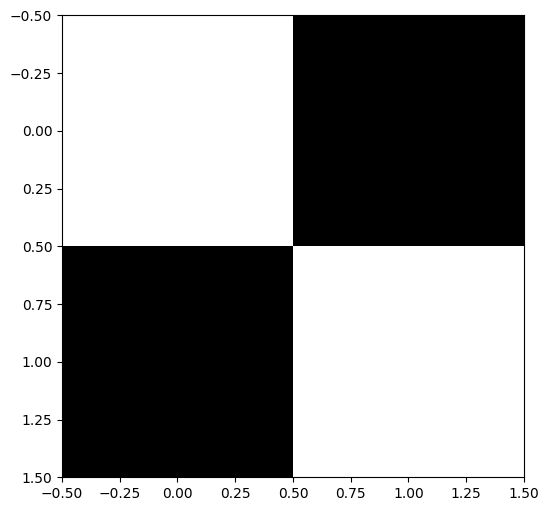

In [102]:
dibujar(matriz22)

Podemos generalizar lo anterior a un tablero de ajedrez con 64 casillas repartidas en 8 filas y 8 columnas, lo que da lugar a una matriz de blanco y negro y dimensión 8x8.

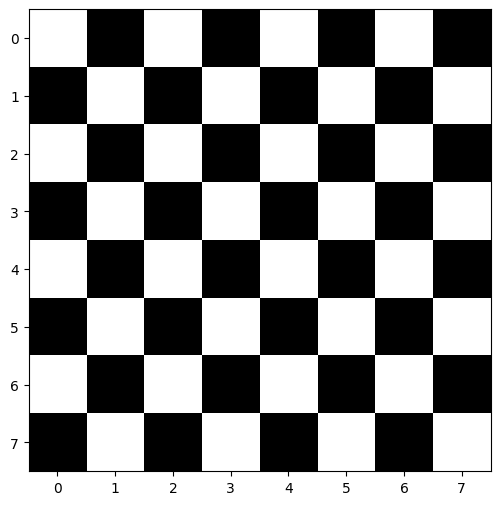

In [103]:
ajedrez = np.array([[255,0,255,0,255,0,255,0],
                    [0,255,0,255,0,255,0,255],
                    [255,0,255,0,255,0,255,0],
                    [0,255,0,255,0,255,0,255],
                    [255,0,255,0,255,0,255,0],
                    [0,255,0,255,0,255,0,255],
                    [255,0,255,0,255,0,255,0],
                    [0,255,0,255,0,255,0,255]])
dibujar(ajedrez)

Hemos visto pues, que podemos crear imágenes en blanco y negro a través de matrices con valores 0 y 255, y visualizarlas fácilmente en Python. Cuando aumentamos la dimensión de la matriz podemos generar imágenes con más detalles variando los colores de las celdas. Empieza entonces a tener sentido el concepto de pixel de una imagen, como un punto (cuadrado) de color en la imagen.

## <font color='steelblue'> 3. Manipulación de imágenes por píxeles

Cuando hemos definido una imagen a través de una matriz, podemos manipularla fácilmente utilizando las propiedades de los *arrays* de *NumPy*. Veamos cómo resolver algunas manipulaciones sencillas, en la que un pixel en la imagen equivale a una celda o cuadrícula en la matriz que la representa. Puesto que estamos en dos dimensiones, la primera dimensión se refiere a las filas, o lo que es lo mismo, a la altura de la imagen desde el extremo superior izquierdo, y la segunda dimensión se refiere a las columnas, es decir, al ancho de la imagen, utilizando como referencia el extremo superior izquierdo. El valor numérico en cada celda representará el nivel de gris de la imagen en cada píxel.

### <font color='steelblue'>Selección

Para seleccionar un pixel en una imagen que hemos construido a partir de una matriz, hemos de referir la fila y la columna correspondiente, donde fila=0 y columna=0 identifica la primera celda de la matriz, o lo que es lo mismo, el pixel más extremo en la parte superior izquierda de la imagen. Las filas avanzan hacia abajo de la imagen y las columnas hacia la derecha. Así el valor contenido en el pixel ubicado en cierta `fila` y cierta `columna` de la `matriz` con la que se ha definido la imagen a tratar, se selecciona con la sintaxis:

```
matriz[fila, columna]
```

Veamos varios ejemplos de selección a continuación, para mostrar el color en diferentes píxeles de una imagen (identificando cada pixel con una celda).


In [104]:
# color de ajedrez en el pixel inferior derecho (fila8-columna8)
print(ajedrez[7, 7])

255


Recuerda que la selección en una matriz normal de Python se hacía con doble corchete, que ahora desaparece. La selección de píxeles, o lo que es lo mismo, de elementos de una matriz, también puede hacerse con números negativos, es decir, empezando a contar desde el final: la última fila y la última columna, o lo que es lo mismo, el pixel en el extremo inferior derecho de la imagen.

In [105]:
# color del ajedrez en el pixel de la penúltima fila y última columna
print(ajedrez[-2, -1])

0


### <font color='steelblue'>Cambio de color

Una vez sabemos seleccionar un pixel en una imagen a través del elemento que lo identifica en la matriz que la define, podemos fácilmente modificar el color sin más que hacer una asignación en el rango de valores posibles, esto es, un valor entero entre 0 (negro) y 255 (blanco).

Probamos a hacer varias modificaciones en el color de las imágenes que hemos definido anteriormente, y a visualizarlas una vez modificadas.

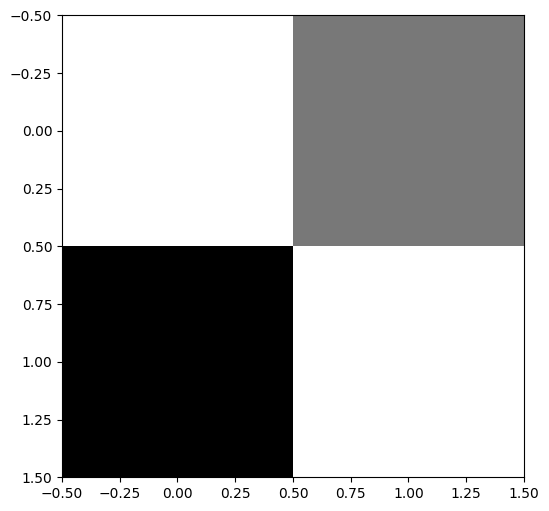

In [106]:
# modificamos el color de un pixel en matriz22
matriz22[0, 1] = 120
dibujar(matriz22)

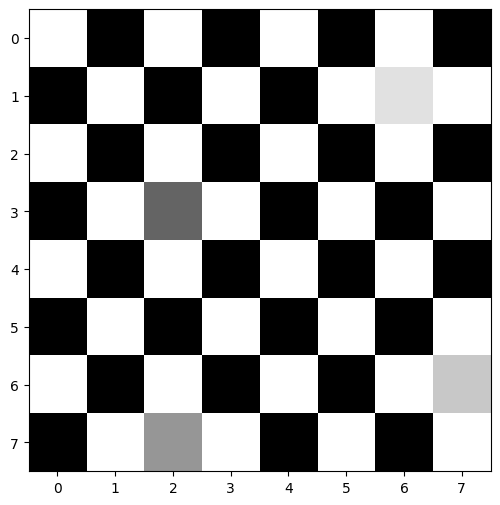

In [107]:
# modificamos el color de varios pixeles en el ajedrez
ajedrez[3, 2] = 100
ajedrez[-2, -1] = 200
ajedrez[7, 2] = 150
ajedrez[1, 6] = 225
dibujar(ajedrez)

## <font color='steelblue'> 4. Manipulación de imágenes por secciones

Además de acceder a píxeles determinados, también podemos seleccionar filas completas de píxeles, columnas completas e incluso rangos o secuencias personalizadas, seleccionándolos sobre la matriz que define la imagen con la sintaxis:
```
matriz[ini_f:fin_f:paso_f,ini_c:fin_c:paso_c]
```
donde `ini` identifica el índice (entero) del elemento de inicio a considerar, por filas (`_f`) o columnas (`_c`), `fin` señala el índice final, y `paso` indica el tamaño del salto a dar entre el inicio `ini` y el final `fin`.

Los valores por defecto que se usan cuando no se incluyen en el código son `ini=0`, esto es, el primer elemento, `fin=max()` el valor máximo para los índices (número de filas o de columnas), y `paso=1`. El paso además, se puede obviar. Así la selección `(::)` es equivalente a `(:)`. Veamos cómo funciona con una de las matrices ya definidas.

In [108]:
# No incluimos ningún valor: selecciona la matriz completa
print(matriz22[::,::])
# obtenemos la misma selección al obviar el paso:
# todas las filas y todas las columnas
print(matriz22[:,:])

[[255 120]
 [  0 255]]
[[255 120]
 [  0 255]]


### <font color='steelblue'>Selección de filas

Para seleccionar sólo una fila `f`, la fijamos en el primero de los argumentos de la selección (filas) y seleccionamos todas las columnas en el segundo argumento (columnas):
```
# selección de la fila f
matriz(f,:)
```



### <font color='steelblue'>Selección de columnas

Para seleccionar sólo una columna `c`, seleccionamos todas las filas en el primer argumento de la selección (filas), y fijamos el valor `c` en el segundo argumento (columnas):
```
# selección de la columna c
matriz(:,c)
```


### <font color='steelblue'>Selección de rangos

Cuando queremos seleccionar un subconjunto de filas y columnas, procedemos con la selección por rangos. Si queremos todos los elementos en ciertas filas y ciertas columnas, obviaremos el paso. Si queremos cierta secuencia periódica de salto `p`, como por ejemplo todos los elementos pares o impares, hemos de incluir el valor para el salto (en el caso de pares o impares, 2).

Veamos varios ejemplos sobre la imagen del ajedrez.

[[255   0 255   0 255   0 255   0]
 [  0 255 100 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]]


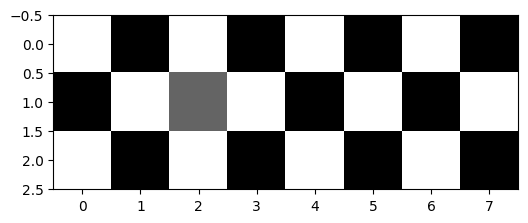

In [109]:
# seleccionamos las filas 3, 4 y 5, y todas las columnas
print(ajedrez[2:5, :])
dibujar(ajedrez[2:5, :])

Somos insistentes, pero es muy importante recordar que, mientras que las filas (o columnas) las identificamos como fila 1, 2, 3, ..., los índices con los que las reconocemos en Python son, respectivamente 0, 1, 2, ....

Así, si queremos seleccionar todas las filas pares (2,4,6,...) y las columnas impares (1,3,5,...), marcamos exclusivamente el paso 2, y el valor inicial para filas y columnas: 1 para pares, y 0 (o nada) para impares.

## <font color='steelblue'>5. Procesado básico de imágenes

Hasta ahora hemos dibujado imágenes que hemos creado a partir de matrices. Cuando tenemos un fichero de imagen (como un .png o .jpg), también podemos leerlo y convertirlo en una matriz bidimensional con tantas filas como píxeles tiene la imagen en la vertical, y tantas columnas como píxeles en la horizontal o ancho de la imagen. Cada uno de los elementos de la matriz, para las imágenes en escala de gris, toma el valor correspondiente al nivel de gris del pixel (fila/columna) correspondiente. Una vez hemos "traducido" una imagen a una matriz, podemos operar con los elementos de la matriz y con dichas operaciones generar distintas transformaciones o procesados, esto es, distintas imágenes, mejorando  intensidad, contraste, reduciendo resolución, etc.

En esta sección trabajamos con algunos procesamientos básicos de imágenes, para entender que realmente se resuelven a partir de cálculos con las matrices que las identifican. El procesamiento profesional de imágenes se resuelve con otras funciones más complicadas a las que vemos aquí, pero la dinámica es similar: aplicar operaciones y transformaciones a la matriz que representa la imagen.

Nuestro primer reto es pues, conseguir un conversor capaz de leer un fichero de imagen y generar la matriz asociada a la imagen. Esto lo hacemos con la **función `imread` del módulo imageio**, que hemos de importar. La **función `imread`** recibe como argumentos el nombre del fichero con la imagen (en forma de cadena de texto), y el formato para leer el fichero (por defecto, imageio selecciona el formato adecuado basado en el nombre del fichero y su contenido). Usamos también el parámetro `mode` con valor 'F' para indicar que los pixels están en formato de 32-bit float.

La documentación completa se puede consultar en la documentación de la librería IMAGEIO en https://imageio.readthedocs.io/en/stable/_autosummary/imageio.v2.imread.html

 Veamos cómo opera con el fichero de imagen 'radiografia.jpg', precargado en el espacio de trabajo virtual con la configuración de este cuaderno.

In [110]:
# Cargamos las imágenes en nuestro directorio de contenidos
# Cargamos imágenes para procesar
img = ["radiografia", "ejercicio5", "covid", "no_covid"]
for i in img:
  !wget {f"https://raw.githubusercontent.com/ia4legos/Statistics/main/images/{i}.jpg"}

# Inicialización de módulos
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# importamos función para leer imágenes y cargamos una .jpg (propia)
import imageio.v2 as imageio

imagen = imageio.imread("radiografia.jpg", mode= 'F')

#imageio.help('jpg')

--2025-10-02 09:52:13--  https://raw.githubusercontent.com/ia4legos/Statistics/main/images/radiografia.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159400 (156K) [image/jpeg]
Saving to: ‘radiografia.jpg.1’

radiografia.jpg.1   100%[===================>] 155.66K  --.-KB/s    in 0.02s   

2025-10-02 09:52:13 (6.97 MB/s) - ‘radiografia.jpg.1’ saved [159400/159400]

--2025-10-02 09:52:14--  https://raw.githubusercontent.com/ia4legos/Statistics/main/images/ejercicio5.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 175367 (17

Una vez cargada, comprobamos su tamaño con la **función `shape`**. En nuestro caso, la matriz cuenta con 1022 filas y 1158 columnas, es decir, la imagen tiene 1022 píxeles de alto por 1158 píxeles de ancho. Cada celda de la matriz, que visualizamos parcialmente porque la matriz es muy grande y no cabe en pantalla, tiene un número que representa el nivel de gris de la imagen en ese píxel (fila/columna).

In [111]:
# Mostramos la dimensión y una parte de la matriz
print("Tamaño:",imagen.shape)
print(imagen)


Tamaño: (1022, 1158)
[[30. 30. 29. ... 12. 13. 13.]
 [30. 29. 29. ... 12. 12. 13.]
 [30. 29. 30. ... 12. 12. 12.]
 ...
 [ 5.  2.  0. ... 11. 11. 11.]
 [ 5.  2.  0. ... 11. 11. 11.]
 [ 4.  1.  0. ... 11. 11. 11.]]


Para dibujarla vamos a estandarizar los valores de la matriz dividiéndolos por el máximo, 255. Convertimos así la escala de grises con enteros entre 0 y 255, a una escala continua en $[0,1]$. Reprogramamos a continuación la función `dibujar` para ajustar estos extremos de la escala de grises, con los argumentos `vmin` y `vmax` en la **función `imshow()`**. Y dibujamos la imagen.

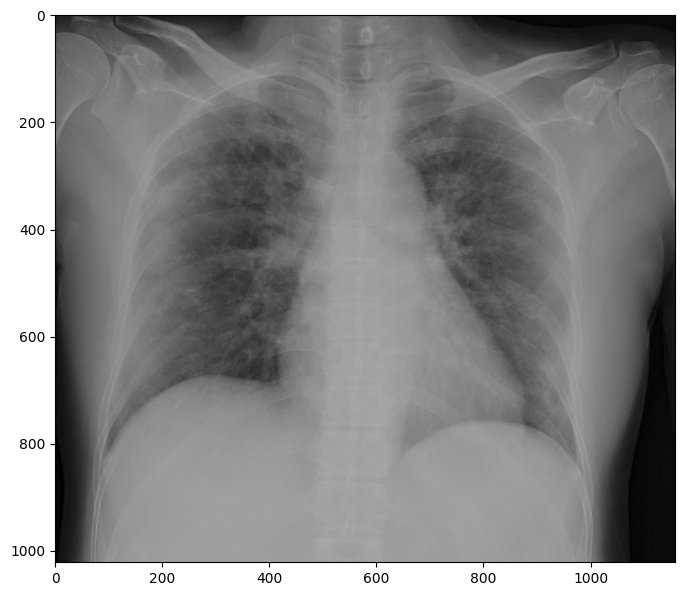

In [112]:
# reescalamos los números que definen la escala de gris
imagen = imagen / 255

# reprogramamos la función para dibujar, encajada en la escala [0,1]

def dibujar_img(matriz):
  plt.figure(figsize=(8,8))
  plt.imshow(matriz, cmap="gray", vmin=0, vmax=1)

# dibujamos la imagen
dibujar_img(imagen)

Vemos que tenemos la imagen de una radiografía de los pulmones.

### <font color='steelblue'>Recorte y zoom

Si queremos **enfocar** la imagen sobre una zona en particular, podemos utilizar la **selección por rango** que trabajamos en secciones anteriores. Para afinar con la selección del rango (zona) de interés hay que tener en cuenta la indexación de las filas y las columnas: la fila 1-columna 1 tiene como índice [0,0] e identifica la esquina superior izquierda de la imagen; la fila 1022-columna 1128 (las últimas) identifican la esquina inferior derecha de la imagen y tiene como índice [1021,1127].

Seleccionamos pues como zona de foco o recorte, la sección entre los píxeles indexados como 200 y 599 en la vertical, y entre 100 y 499 en la horizontal.

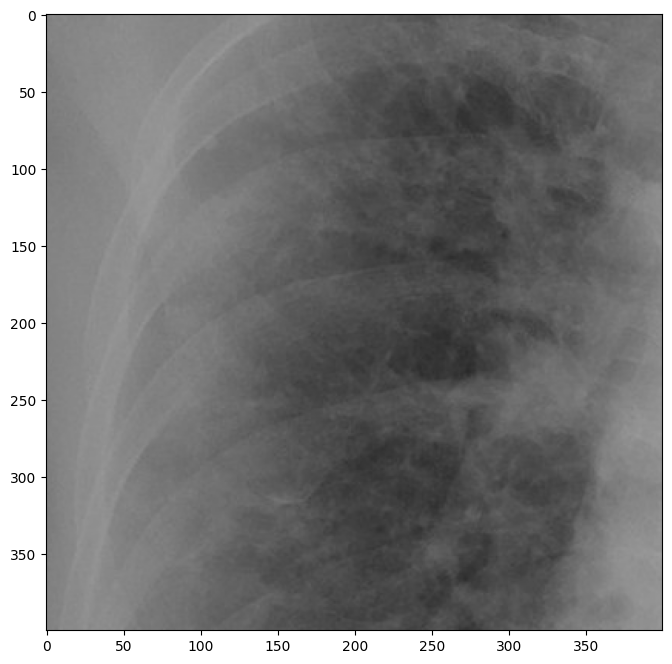

In [113]:
# Foco o recorte de imagen en una zona
recorte = imagen[200:600, 100:500]
dibujar_img(recorte)

Puesto que la función para dibujar mantiene las dimensiones fijas, lo que hemos conseguido con el recorte es realmente un **zoom** de la zona seleccionada, que puede ser útil al profesional para visualizar mejor patologías localizadas.

### <font color='steelblue'>Rotación

En ocasiones interesa rotar una imagen para visualizarla mejor. Para ello utilizamos la **función `rot90` del módulo NumPy**, que nos permite girar la imagen 90 grados en sentido contrario a las agujas del reloj.


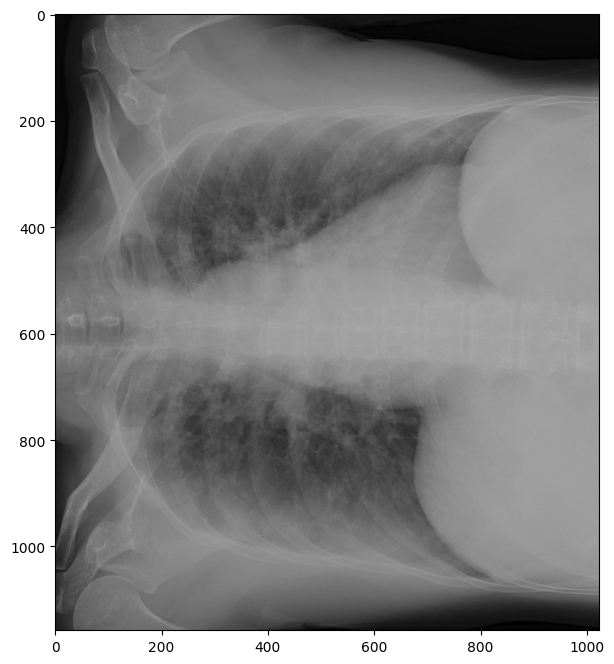

In [114]:
# Rotación de 90 grados de una imagen, en sentido antihorario
imagen_rotada = np.rot90(imagen)
dibujar_img(imagen_rotada)

Si queremos girar la imagen más de 90 grados, pero siempre en múltiplos de 90 grados, esta función admite otro argumento con el que se puede especificar el número de volteos de 90 grados a dar. Por defecto es 1, pero si utilizamos 2, tendremos una rotación de 180 grados (la imagen boca abajo), y con un 3 tendremos un giro de 270 grados, o lo que es lo mismo, 90 grados en sentido horario respecto de la imagen original.

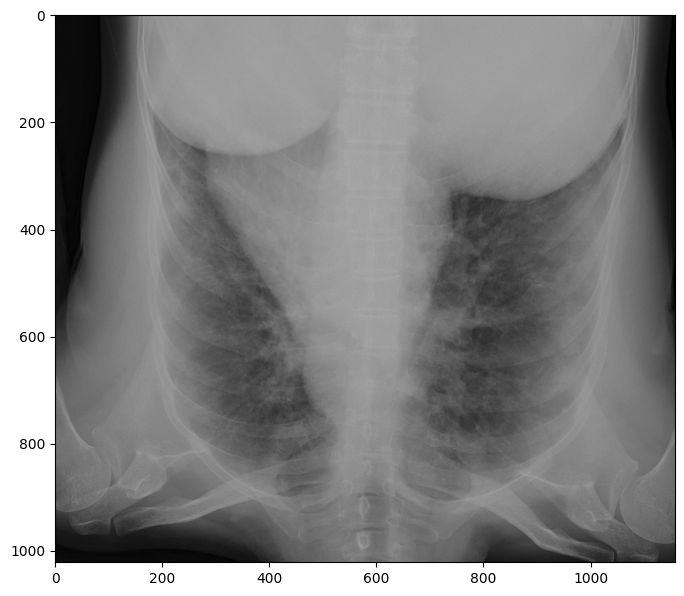

In [115]:
# Rotación de 180º= 2 giros de 90 grados
dibujar_img(np.rot90(imagen, 2))

Una alternativa para invertir una imagen de arriba a abajo (con una rotación de 180 grados) es utilizar la **función `flipud`, también del módulo NumPy**.

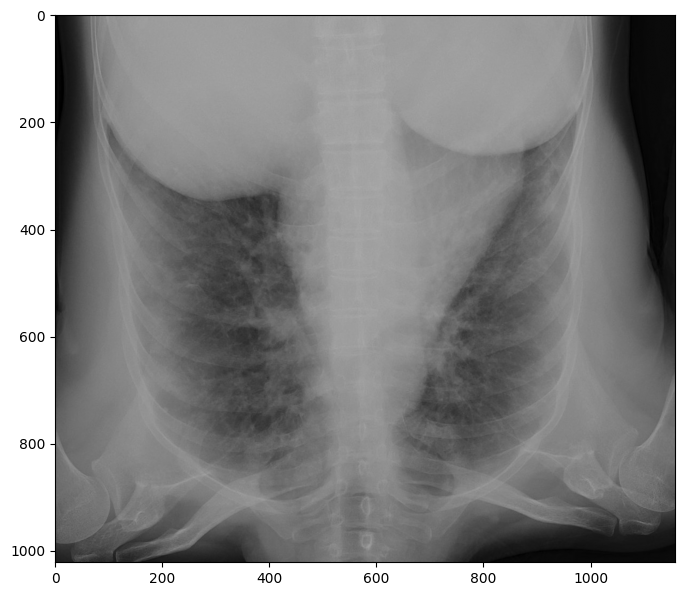

In [116]:
# Rotación de 180º= 2 giros de 90 grados
dibujar_img(np.flipud(imagen))

Por último, si queremos invertir la imagen a modo de espejo, podemos utilizar la **función `fliplr`, también de *NumPy***.

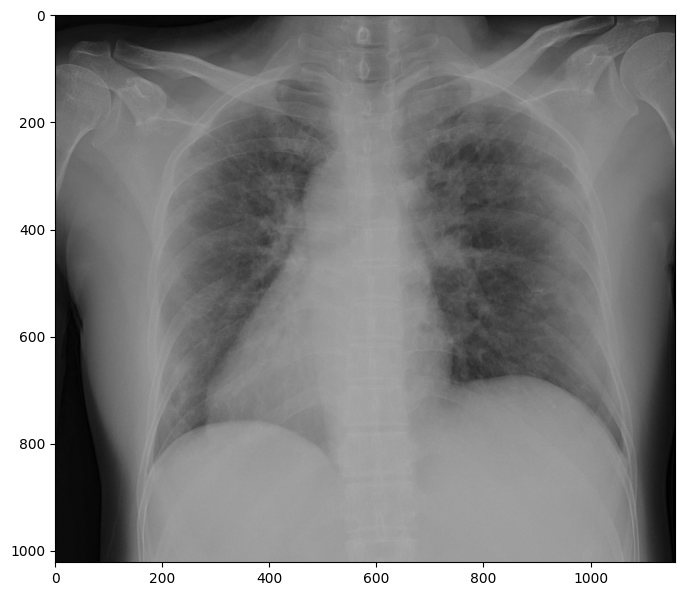

In [117]:
# inversión de la imagen en modo espejo
dibujar_img(np.fliplr(imagen))

### <font color='steelblue'>Reducción de imágenes

La **resolución de una imagen** se define como el número de píxeles, esto es, los puntos que contiene una imagen, y se especifica en términos de píxeles por pulgada (*ppi* en inglés). El número de ppi siempre está relacionado con la anchura y longitud de la imagen, que se expresan en píxeles.
La resolución y las dimensiones determinan la dimensión del fichero de imagen y por supuesto la calidad de visualización: a mayor resolución/dimensión, mejor visualización.

En ocasiones nos puede interesar reducir la resolución de una imagen para disminuir así su tamaño y mejorar su portabilidad. Un modo sencillo de reducir resolución es reduciendo el número de filas y de columnas, cuidando la pérdida de calidad que se produce.

Con *Numpy* podemos reducir fácilmente la dimensión de una imagen seleccionando secuencias de píxeles por filas y columnas con cierto salto fijo `p` (para no perder la esencia de la imagen y recorrerla entera). El efecto visual que se produce es el desenfoque de la imagen, pero como hemos dicho, puede no afectar de modo crítico cuando pretendemos visualizar o imprimir la imagen con un tamaño pequeño (como una miniatura en una web, o una foto de carnet).

Así, si elegimos una selección de píxeles con un paso 3, `::3`, indicamos que la imagen mantiene un píxel de cada 3; si esto lo aplicamos a filas y columnas, `[::3, ::3]`, esta selección la hará al recorrer filas y columnas. Veamos el efecto visual de aplicar distintos pasos a la imagen de la radiografía.



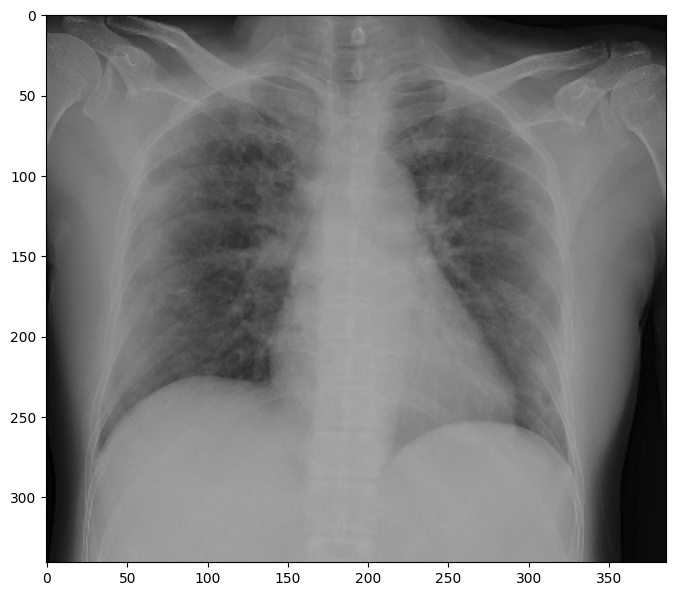

In [118]:
# selección de un pixel por cada 3 (filas y columnas)
dibujar_img(imagen[::3, ::3])

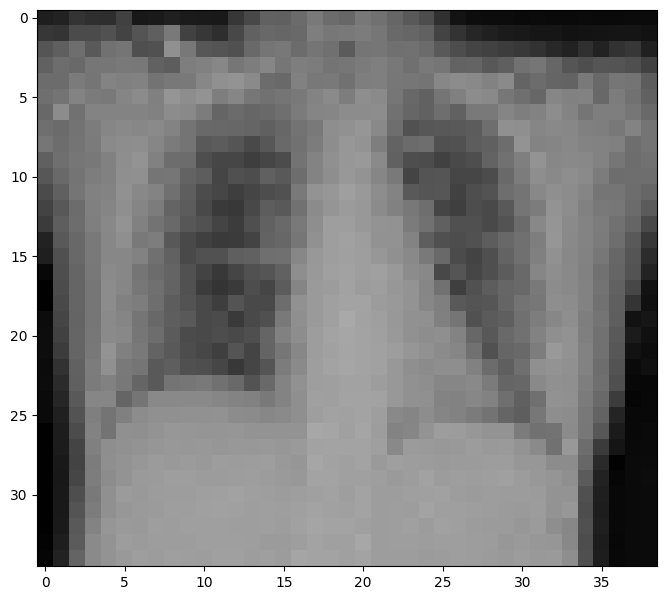

In [119]:
# selección de un pixel por cada 30 (filas y columnas)
dibujar_img(imagen[::30, ::30])

Si bien la reducción que se consigue al seleccionar un píxel de cada 3 al recorrer filas y columnas se percibe como una pérdida leve de nitidez, es clara la pérdida de resolución de la imagen cuando se selecciona solo un píxel por cada 30, tanto a lo ancho como a lo largo de la imagen.

Pero si reducimos el lienzo donde visualizar la imagen (por ejemplo, creamos una miniatura), no se aprecia tanto la pérdida de calidad de la imagen:

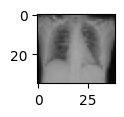

In [120]:
def dibujar_img2(matriz):
  plt.figure(figsize=(1,1))
  plt.imshow(matriz, cmap="gray", vmin=0, vmax=1)

dibujar_img2(imagen[::30, ::30])

### <font color='steelblue'>Intensidad

Cuando cargamos la imagen de la radiografía, ya convertimos la escala de grises 0-255, a una escala continua en el intervalo [0,1]. Este escalamiento da posibilidades para generar imágenes que potencien las zonas más oscuras o por contra las más claras, para captar detalles más sensibles a fondos oscuros o a fondos claros. Esto se consigue operando sobre los valores de gris para potenciar unas tonalidades u otras, y así aumentar o disminuir la intensidad de la imagen en determinadas zonas de interés.

Este es el sentido de los **filtros** que se aplican a las imágenes, con los que se consigue **suavizar** una imagen reduciendo la cantidad de variaciones de intensidad entre píxeles vecinos,  o la **eliminación de ruido**, con la que se eliminan píxeles con intensidad muy diferente a sus vecinos, o el **realce** o **detección de bordes**, entre otros, para identificar zonas donde se produce un cambio brusco de intensidad. La intensidad del color en una imagen en escala de grises viene dada por el nivel de gris.

Veamos el efecto de aplicar distintas operaciones a las matrices.

En primer lugar probamos con la división y el producto: al dividir la matriz de la imagen por 2, **disminuye su intensidad** (se genera una imagen más oscura); al multiplicarla por 2, **aumenta su intensidad**.


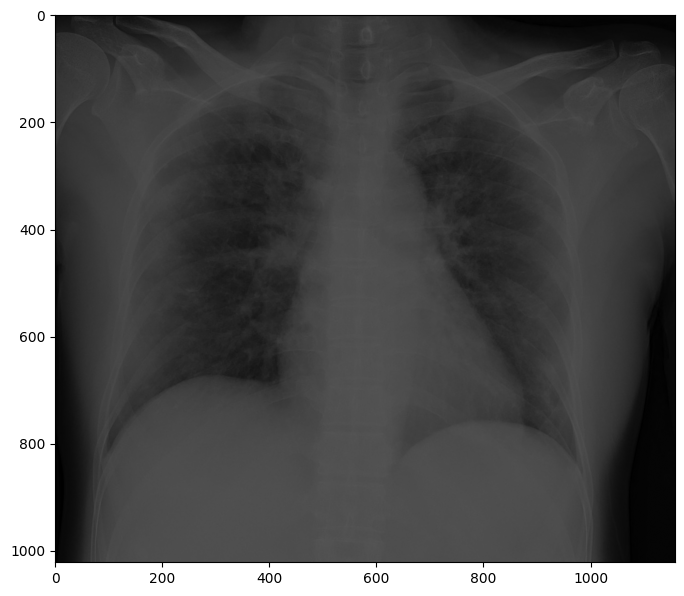

In [121]:
# disminución de la intensidad de la imagen: división
dibujar_img(imagen/2)

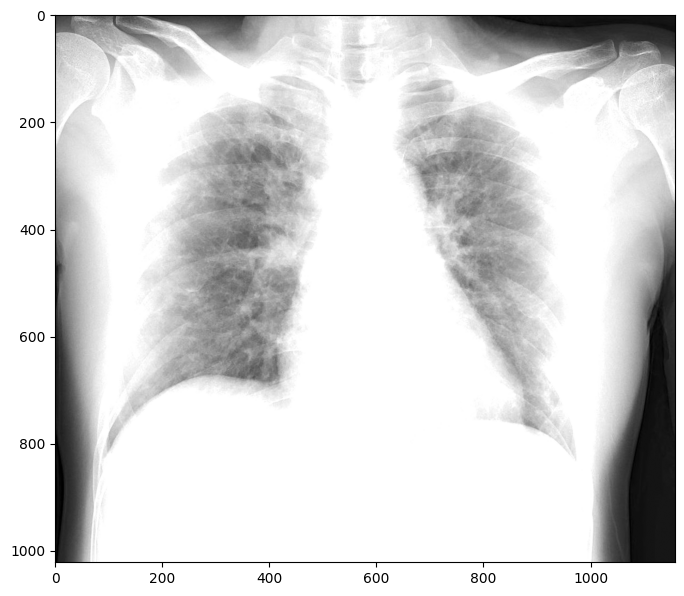

In [122]:
# aumento de la intensidad de la imagen: multiplicación
dibujar_img(imagen*2)

Podemos aplicar igualmente otras operaciones, como las potencias o raíces. Si elevamos al cuadrado la matriz, conseguimos **oscurecer los píxeles grises**. Si queremos **alumbrar los píxeles grises** debemos realizar la operación contraria, es decir, la raíz cuadrada. El módulo de *NumPy* contiene la función `sqrt` que realiza este cálculo.

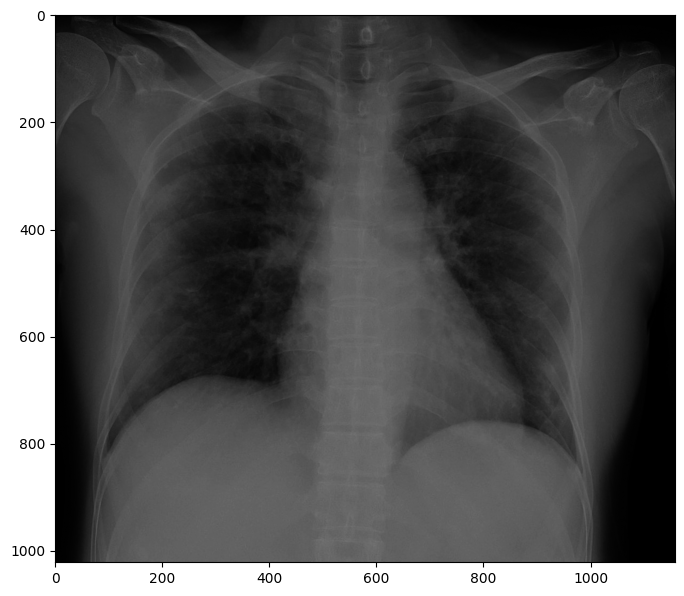

In [123]:
# Oscurecimiento de zonas grises: cuadrado de la matriz
dibujar_img(imagen**2)

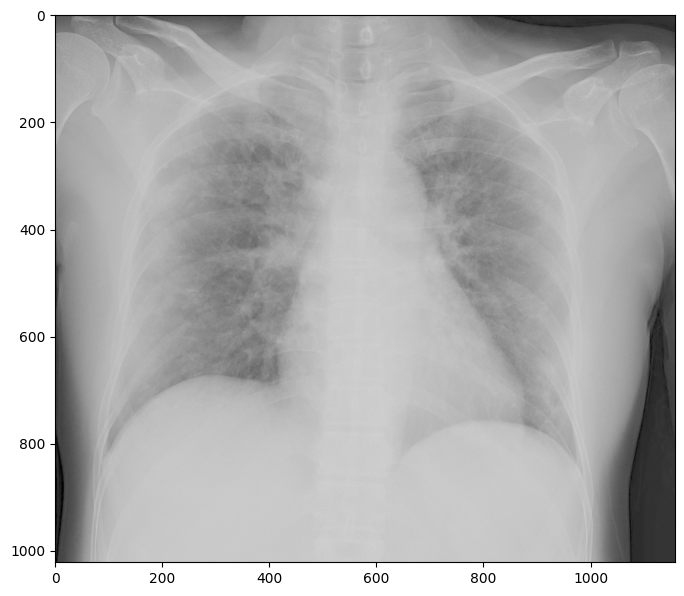

In [124]:
# Iluminación de zonas grises: raíz cuadrada de la matriz
dibujar_img(np.sqrt(imagen))

### <font color='steelblue'>Fraccionamiento del nivel de gris

Otro procesado habitual con las imágenes en escala de grises tiene que ver con el **fraccionamiento del nivel de gris**, también llamado **enmascaramiento** o **filtro umbral**. Cuando se quiere destacar un rango específico del nivel de gris, se asigna un valor alto a todos los niveles de gris del rango de interés, y uno bajo a los restantes (o viceversa). Quedan entonces zonas que no se van a distinguir, pues quedan confundidas con todos los píxeles del mismo rango de grises.

Por ejemplo, fraccionamos a continuación el nivel de gris en dos únicos niveles: blanco (valor 1 en la matriz) para los píxeles cuyo nivel original está por encima del umbral 0.5, y negro (valor 0 en la matriz) para los que tienen un nivel de gris inferior. Esta transformación la resolvemos planteando una condición sobre los elementos de la matriz, de modo que al testar la condición, se asigna un 1 a los que la cumplen y un cero a los que no, para generar una nueva imagen exclusivamente con ceros y unos. Veamos cómo funciona.


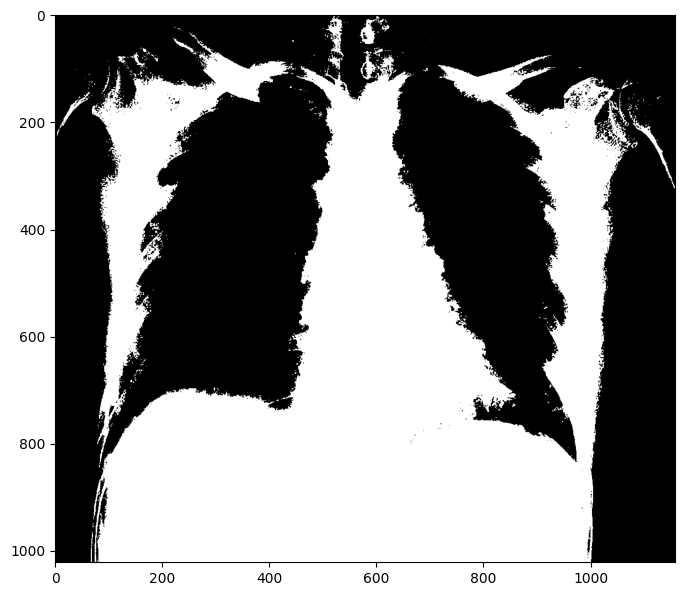

In [125]:
# fraccionar el nivel de gris:
# asigna 1 a los píxeles con nivel de gris >0.5
# y 0 al resto
dibujar_img(imagen > 0.5)

Para conseguir el **negativo** de la imagen anterior, basta con invertir la condición, para asignar 0 donde antes asignábamos 1 y viceversa.


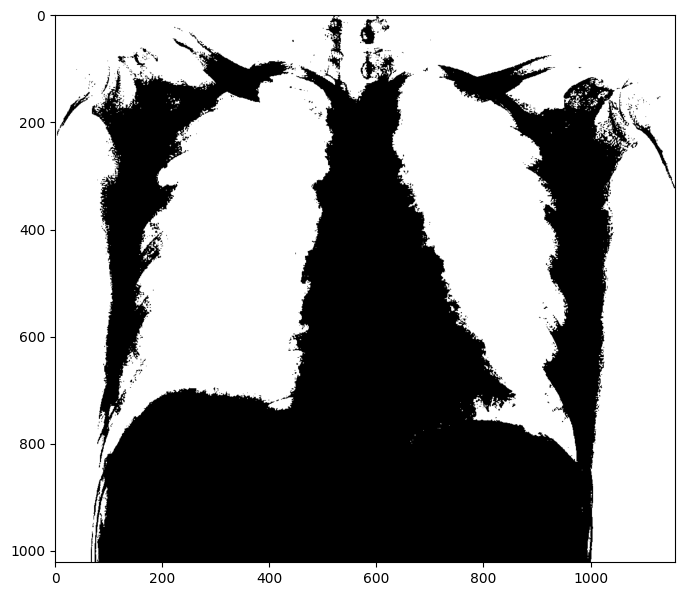

In [126]:
# negativo de la imagen previa
dibujar_img(imagen < 0.5)

Cuando queremos aplicar una procesado cualquiera a una imagen y conservar dicho procesado, podemos optar, para salvaguardar la imagen (matriz) original y hacer una copia de esta sobre la que se aplican las transformaciones de interés. Para ello disponemos de la **función `copy`**, que aplicada a una imagen (matriz) genera un clon.

Supongamos que sobre una imagen cualquiera queremos modificar y unificar (a cero) el nivel de gris de todos los píxeles con un nivel de gris inferior a 0.5, manteniendo los restantes a su nivel original. Vamos a hacer una copia de la imagen original y aplicar el valor 0 solo a aquellos elementos de la matriz de la imagen que cumplan la condición `nivel<0.5`, esto es, los que quedan por debajo del umbral 0.5, manteniendo igual el resto. Remarcamos así las zonas más oscuras.

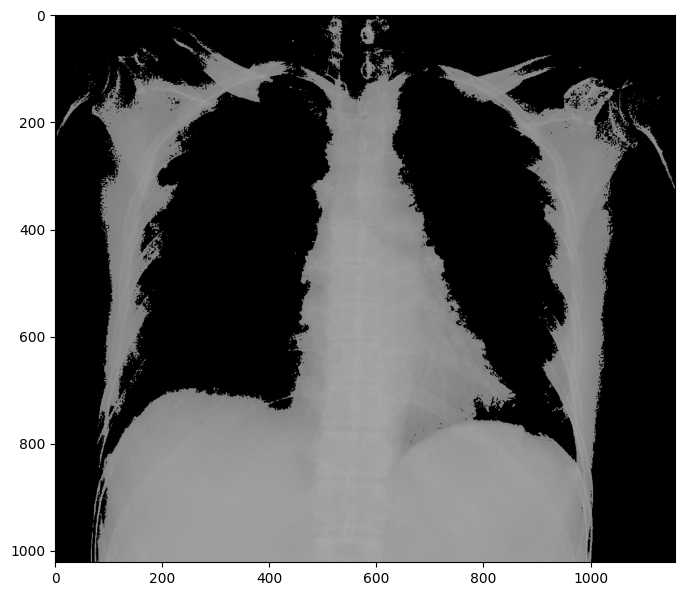

In [127]:
# hacemos una copia de la imagen
copia = imagen.copy()
# aplicamos una transformación umbral a los elementos que cumplen la condición
copia[copia<0.5] = 0
# dibujamos la imagen resultante
dibujar_img(copia)


Si optamos por ver con más claridad las zonas más claras (menos grises), podemos optar por modificar los píxeles con un nivel de gris superior a 0.65, asignándole un valor de 1.


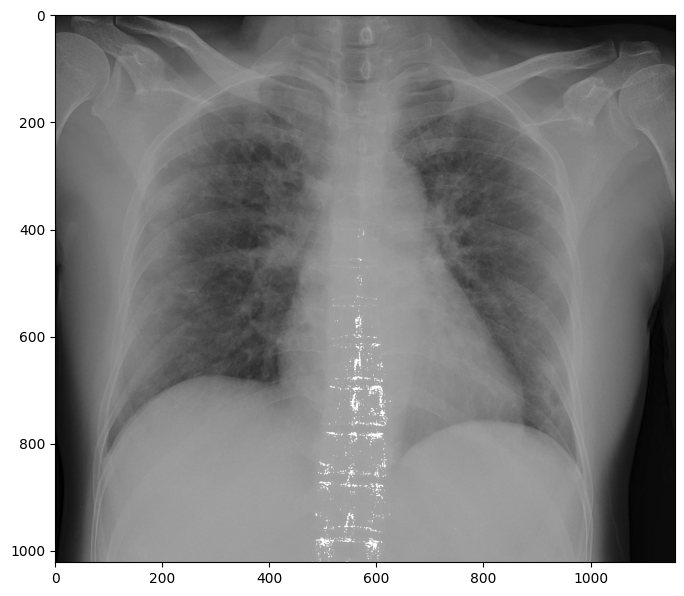

In [128]:
# hacemos una copia de la imagen
copia = imagen.copy()
# aplicamos una transformación umbral a los elementos que cumplen la condición
copia[copia>0.65] = 1
# dibujamos la imagen resultante
dibujar_img(copia)

### <font color='steelblue'>Comparación de imágenes

El último tipo de procesamiento de imágenes 2D que trabajamos aquí es el de comparación de imágenes. En el caso de la radiografía torácica, es común que un sanitario quiera comparar la radiografía de un paciente sano con la de uno aquejado de alguna enfermedad respiratoria. Planteamos aquí comparar radiografías torácicas de dos pacientes: uno sano y otro con COVID19. La comparación de imágenes se realiza, al igual que el resto de procesados, a través de la comparación de las matrices que representan las imágenes, esto es, de los niveles de gris en sus celdas.

Leemos las radiografías de los dos pacientes, las estandarizamos en la escala de grises [0,1], dividiendo por 255, y las visualizamos.

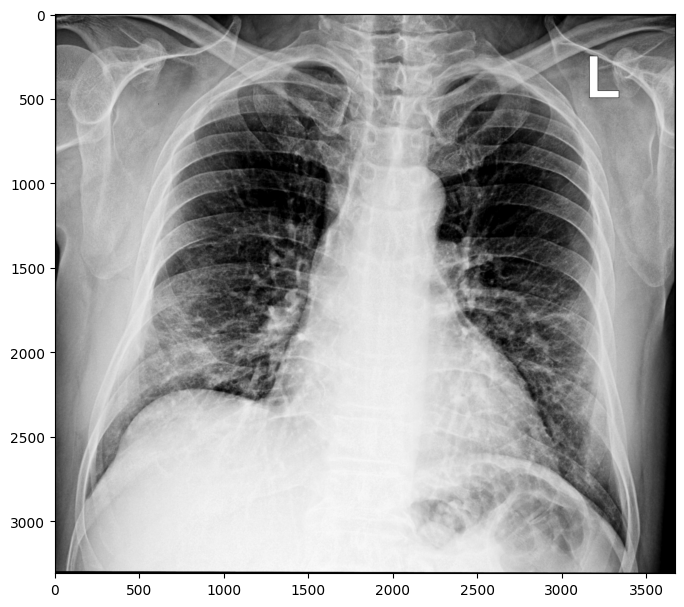

In [129]:
# leemos la radiografía del paciente con covid19
covid = imageio.imread("covid.jpg", mode='F')
# estandarizamos los niveles de gris
covid = covid / 255
# visualizamos la imagen
dibujar_img(covid)

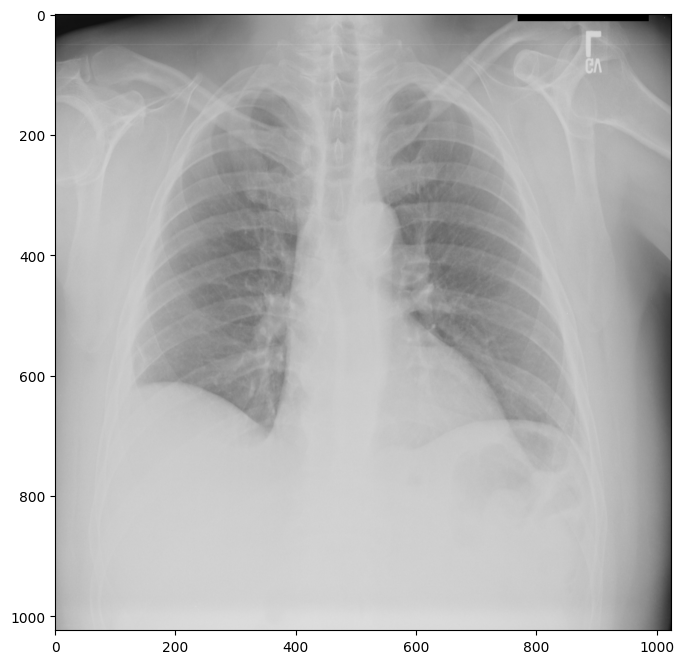

In [130]:
# leemos la radiografía del paciente sin covid19
no_covid = imageio.imread("no_covid.jpg", mode='F')
# estandarizamos los niveles de gris
no_covid = no_covid / 255
# visualizamos la imagen
dibujar_img(no_covid)

Comprobamos a continuación el tamaño de ambas, y a pesar de que tienen distinta resolución, abordamos su comparación a través de la identificación de zonas distintas, estableciendo umbrales de gris para comparar las imágenes más fácilmente.

In [131]:
# comprobamos el tamaño de ambas
print(covid.shape)
print(no_covid.shape)

(3308, 3670)
(1024, 1024)


A simple vista se aprecia que el paciente con COVID19 tiene los pulmones mucho más oscuros que el otro. Vamos a aplicar un filtro para resaltar en negro las zonas más oscuras y en blanco el resto.

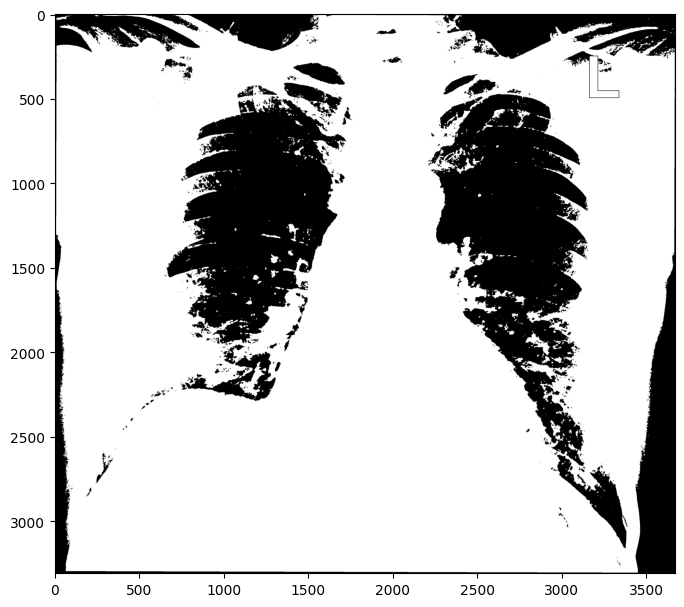

In [132]:
# filtro con umbral 0.4 para el paciente con covid
# i.e. pixel=1 si pixel_imagen >=0.4
dibujar_img(covid >= 0.4)

In [133]:
#calcular % de pixels blancos
filas_covid=covid.shape[0]
columnas_covid=covid.shape[1]

porcentaje_blanco_covid=(covid >= 0.4).sum()/(filas_covid*columnas_covid)
print(f"el porcentaje de blanco de la imagen es {round(porcentaje_blanco_covid*100,2)}")

el porcentaje de blanco de la imagen es 75.09


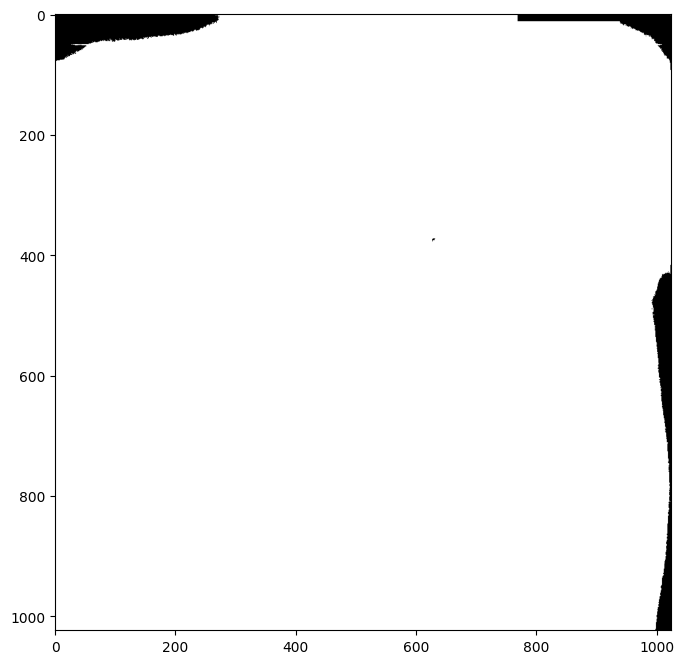

In [134]:
# filtro con umbral 0.4 para el paciente sin covid
dibujar_img(no_covid >= 0.4)

In [135]:
#calcular % de pixels blanco
filas_no_covid=no_covid.shape[0]
columnas_no_covid=no_covid.shape[1]

porcentaje_blanco_no_covid=(no_covid >= 0.4).sum()/(filas_no_covid*columnas_no_covid)
print(f"el porcentaje de blanco de la imagen es {round(porcentaje_blanco_no_covid*100,2)}")

el porcentaje de blanco de la imagen es 97.56


Al aplicar el filtro, la diferencia entre las dos imágenes es absolutamente clara. El **filtro de umbral de gris**, permite pues, diferenciar claramente las dos imágenes.

Por supuesto el valor 0.4 para el umbral lo marca el especialista, y podría haber elegido otro umbral de referencia.



In [136]:
umbrales= list(range(0,11,1))
print(umbrales)
filas_covid=covid.shape[0]
columnas_covid=covid.shape[1]
filas_no_covid=no_covid.shape[0]
columnas_no_covid=no_covid.shape[1]

for i in umbrales:
    umbral = i/10

    porcentaje_blanco_covid=(covid >= umbral).sum()/(filas_covid*columnas_covid)
    porcentaje_blanco_no_covid=(no_covid >= umbral).sum()/(filas_no_covid*columnas_no_covid)
    diff=porcentaje_blanco_covid-porcentaje_blanco_no_covid
    print(f"Para el umbral {umbral} el % de blanco de covid es {porcentaje_blanco_covid*100:05.2f} y la no covid es {porcentaje_blanco_no_covid*100:05.2f}  dif={diff*100:.2f}")


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Para el umbral 0.0 el % de blanco de covid es 100.00 y la no covid es 100.00  dif=0.00
Para el umbral 0.1 el % de blanco de covid es 94.82 y la no covid es 99.51  dif=-4.69
Para el umbral 0.2 el % de blanco de covid es 89.73 y la no covid es 99.32  dif=-9.59
Para el umbral 0.3 el % de blanco de covid es 82.72 y la no covid es 98.74  dif=-16.02
Para el umbral 0.4 el % de blanco de covid es 75.09 y la no covid es 97.56  dif=-22.47
Para el umbral 0.5 el % de blanco de covid es 66.94 y la no covid es 92.88  dif=-25.94
Para el umbral 0.6 el % de blanco de covid es 56.66 y la no covid es 79.65  dif=-22.99
Para el umbral 0.7 el % de blanco de covid es 41.42 y la no covid es 59.03  dif=-17.62
Para el umbral 0.8 el % de blanco de covid es 27.35 y la no covid es 19.16  dif=8.18
Para el umbral 0.9 el % de blanco de covid es 13.01 y la no covid es 00.00  dif=13.01
Para el umbral 1.0 el % de blanco de covid es 00.12 y la no covid es 00.00  dif=0.12


Viendo el comportamiento de los diferentes umbrales, vemos que **con 0.5 se obtiene la mayor diferencia**, que además es negativa, es decir, porcentajes mayores de blanco identifican no-covid y los menores identifican covid.  Podríamos pues, utilizar el porcentaje de pixeles blancos como criterio para decidir automáticamente si padece o no la COVID.